# Optimization-based Signal Decomposition (OSD)

**OSD** casts signal decomposition as a convex (or mildly non-convex)
optimization problem: choose cost functions $\phi_k$ that encode what each
component *should look like*, then solve

$$
\min_{x^1,\ldots,x^K}
\;\sum_{k=1}^{K} w_k\,\phi_k(x^k)
\quad\text{s.t.}\quad
\sum_{k} x^k = y
$$

on the observed samples of $y$.  PySDKit’s implementation uses
**block-coordinate descent with masked proximal operators** (NumPy / SciPy only).

This notebook mirrors the *sine + square wave* convex demo from
[cvxgrp/signal-decomposition](https://github.com/cvxgrp/signal-decomposition)
(`Simple_convex_example-3_ways.ipynb`).

**Reference**

> B. Meyers, S. Boyd. *Signal Decomposition via Masked Proximal Operators.*  
> https://web.stanford.edu/~boyd/papers/sig_decomp_mprox.html

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import OSD
from pysdkit._osd import (
    MeanSquareSmall,
    SmoothSecondDifference,
    SparseFirstDiffConvex,
)

print(OSD())

Optimization-based Signal Decomposition (OSD)


## 2. Principles

| Component | Cost $\phi$ | Intended morphology |
| --- | --- | --- |
| `MeanSquareSmall` | $\|x\|_2^2 / T$ | small residual / noise |
| `SmoothSecondDifference` | $\|D_2 x\|_2^2$ | smooth trend / sinusoid |
| `SparseFirstDiffConvex` | $\|D_1 x\|_1$ | piecewise-constant (TV) |

BCD updates each non-residual component with its proximal map, then sets the
residual so that $\sum_k x^k = y$ exactly on known samples.

## 3. Synthetic sine + square wave

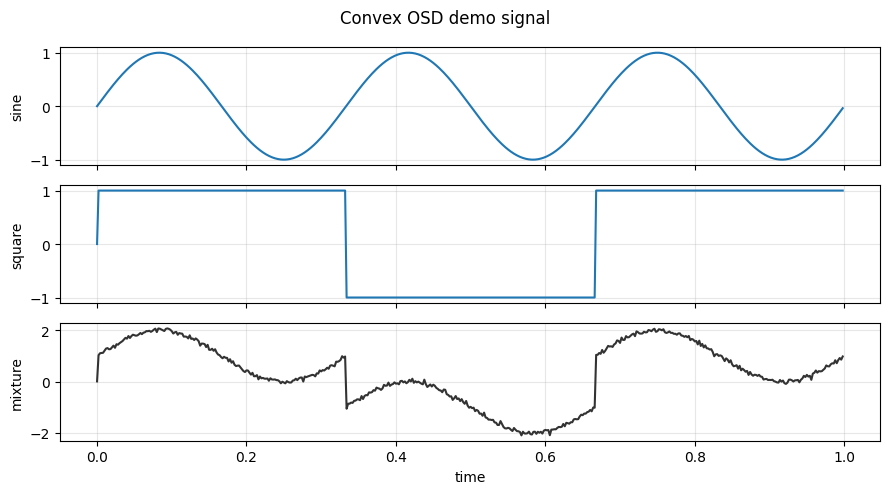

In [2]:
rng = np.random.default_rng(0)
T = 500
t = np.linspace(0, 1, T, endpoint=False)
sine = np.sin(2 * np.pi * 3 * t)
square = np.sign(np.sin(2 * np.pi * 1.5 * t))
y = sine + square + 0.05 * rng.standard_normal(T)

fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, sine)
axes[0].set_ylabel("sine")
axes[1].plot(t, square)
axes[1].set_ylabel("square")
axes[2].plot(t, y, color="0.2")
axes[2].set_ylabel("mixture")
axes[2].set_xlabel("time")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.suptitle("Convex OSD demo signal")
plt.tight_layout()
plt.show()

## 4. Decomposition via preset (or explicit components)

In [3]:
# Equivalent explicit construction:
# comps = [
#     MeanSquareSmall(size=T),
#     SmoothSecondDifference(weight=1e3 / T),
#     SparseFirstDiffConvex(weight=2e0 / T, vmin=-1, vmax=1),
# ]
# osd = OSD(components=comps, max_iter=120)

osd = OSD.preset("convex_demo", length=T, max_iter=120)
X = osd.fit_transform(y)
print("X shape:", X.shape, "  obj:", osd.objective_value)
print("max |recon error|:", np.max(np.abs(X.sum(0) - y)))

X shape: (3, 500)   obj: 0.028564259138937488
max |recon error|: 4.440892098500626e-16


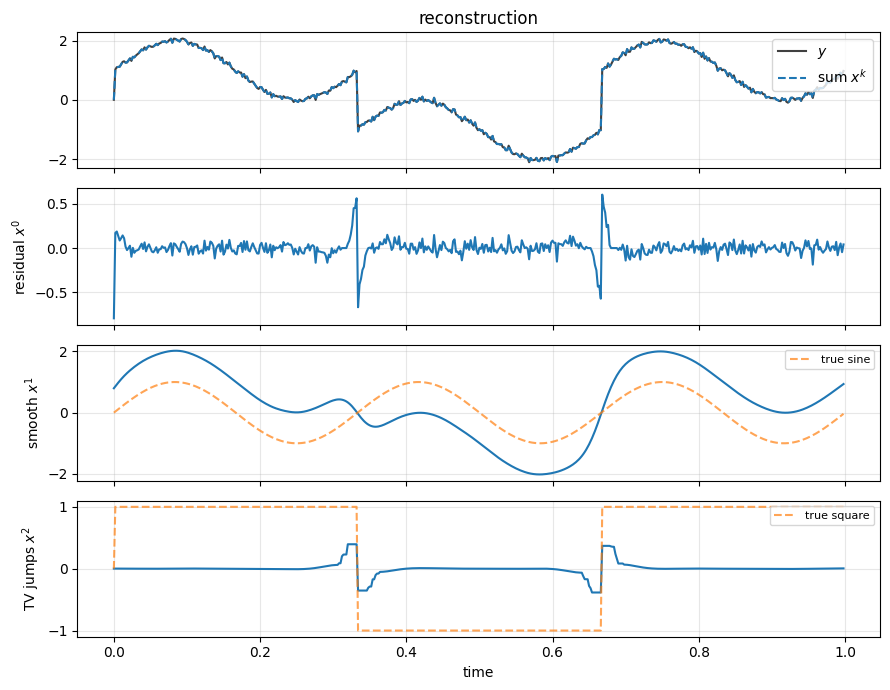

In [4]:
labels = ["residual $x^0$", "smooth $x^1$", "TV jumps $x^2$"]
fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t, y, color="0.25", label="$y$")
axes[0].plot(t, X.sum(0), "--", label="sum $x^k$")
axes[0].legend(loc="upper right")
axes[0].set_title("reconstruction")
for k in range(3):
    axes[k + 1].plot(t, X[k])
    axes[k + 1].set_ylabel(labels[k])
    if k == 1:
        axes[k + 1].plot(t, sine, "--", alpha=0.7, label="true sine")
        axes[k + 1].legend(loc="upper right", fontsize=8)
    if k == 2:
        axes[k + 1].plot(t, square, "--", alpha=0.7, label="true square")
        axes[k + 1].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Takeaways

- OSD is a **modeling language**: change $\phi_k$ to change the decomposition.
- Use `OSD.preset("convex_demo", T)` for a quick start, or pass a custom
  `components=[...]` list.
- `fit_transform` returns `(K, N)` with exact reconstruction on observed
  samples.